In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

from collections import Counter
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shubh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\shubh\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
df = pd.read_excel("dataset -P667.xlsx")
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [3]:
def get_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df['sentiment'] = df['rating'].apply(get_sentiment)
df.head()

,title,rating,body,sentiment
0,Horrible product,1,Very disappointed with the overall performance...,Negative
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative


In [4]:
df['sentiment'].value_counts()

sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64

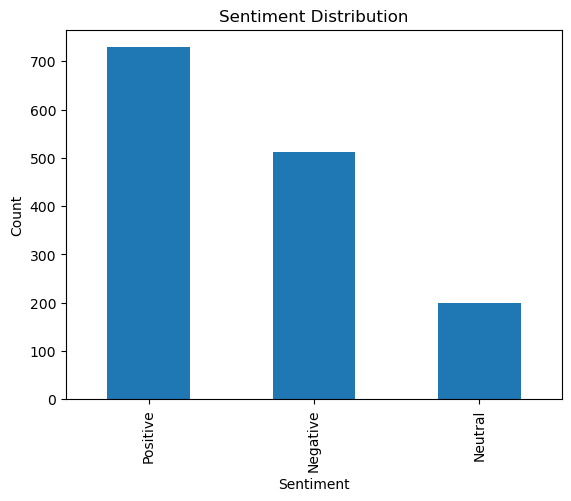

In [5]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

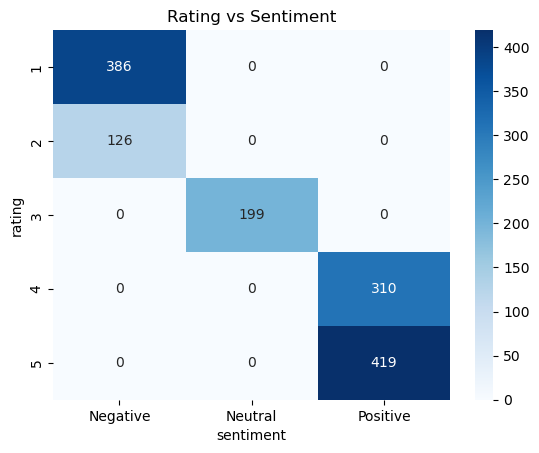

In [6]:
pivot = pd.crosstab(df['rating'], df['sentiment'])
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')
plt.title("Rating vs Sentiment")
plt.show()

In [7]:
df['body_length'] = df['body'].apply(len)
df['word_count'] = df['body'].apply(lambda x: len(x.split()))

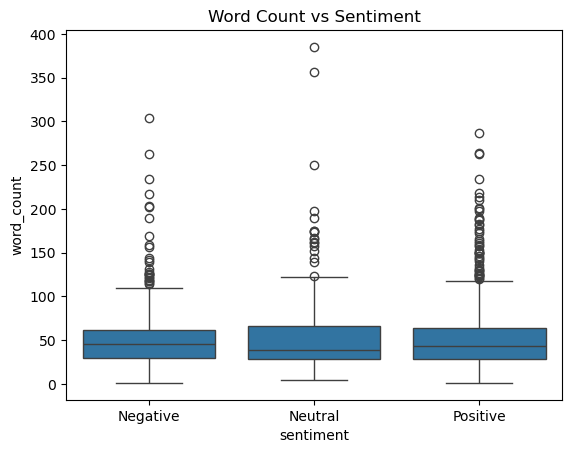

In [8]:
sns.boxplot(x='sentiment', y='word_count', data=df)
plt.title("Word Count vs Sentiment")
plt.show()

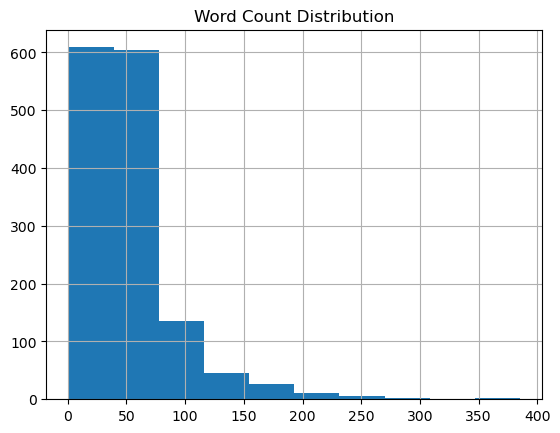

In [9]:
df['word_count'].hist()
plt.title("Word Count Distribution")
plt.show()

In [10]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_body'] = df['body'].apply(clean_text)

In [11]:
all_words = " ".join(df['clean_body']).split()
word_freq = Counter(all_words)
word_freq.most_common(20)

[('is', 3004),
 ('the', 2120),
 ('and', 1599),
 ('phone', 1440),
 ('this', 1344),
 ('to', 1272),
 ('for', 1261),
 ('i', 1230),
 ('not', 1159),
 ('it', 1143),
 ('a', 1104),
 ('good', 1082),
 ('in', 933),
 ('camera', 847),
 ('of', 786),
 ('battery', 712),
 ('with', 697),
 ('but', 655),
 ('very', 625),
 ('samsung', 614)]

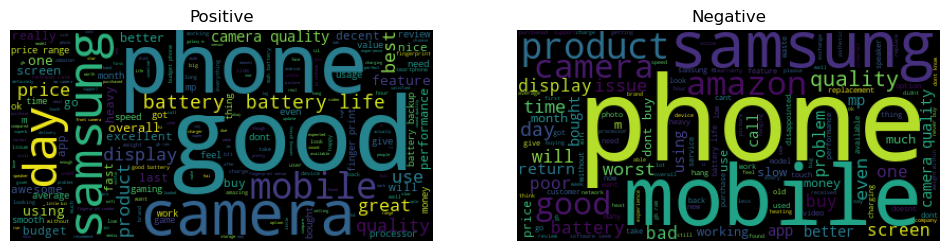

In [12]:
positive_text = " ".join(df[df['sentiment']=="Positive"]['clean_body'])
negative_text = " ".join(df[df['sentiment']=="Negative"]['clean_body'])

wc_pos = WordCloud().generate(positive_text)
wc_neg = WordCloud().generate(negative_text)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(wc_pos)
plt.title("Positive")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(wc_neg)
plt.title("Negative")
plt.axis('off')

plt.show()

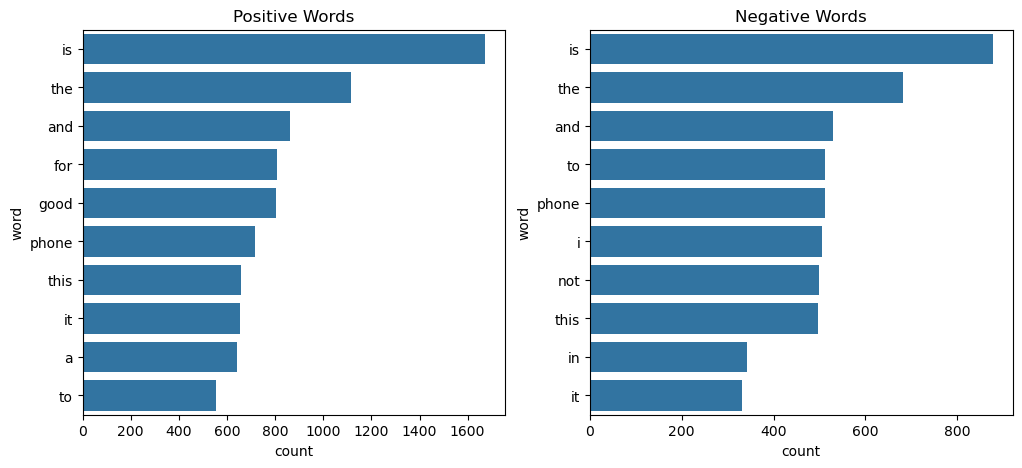

In [13]:
def top_words(text):
    return Counter(text.split()).most_common(10)

pos_df = pd.DataFrame(top_words(positive_text), columns=['word','count'])
neg_df = pd.DataFrame(top_words(negative_text), columns=['word','count'])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.barplot(x='count', y='word', data=pos_df)
plt.title("Positive Words")

plt.subplot(1,2,2)
sns.barplot(x='count', y='word', data=neg_df)
plt.title("Negative Words")

plt.show()

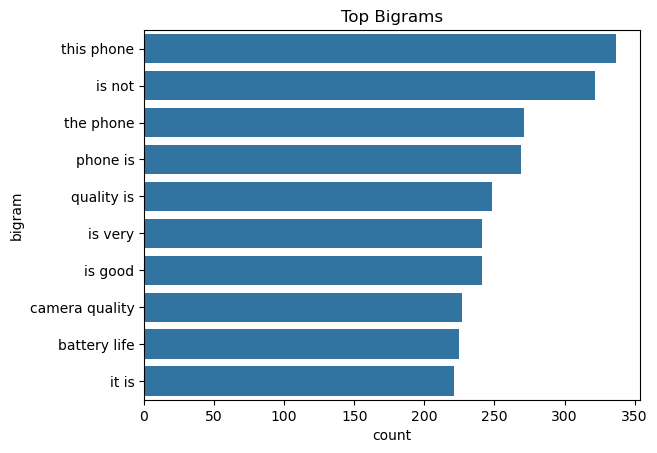

In [14]:
cv = CountVectorizer(ngram_range=(2,2), max_features=10)
X_bigram = cv.fit_transform(df['clean_body'])

sum_words = X_bigram.sum(axis=0)
words = [(word, sum_words[0, idx]) for word, idx in cv.vocabulary_.items()]
words = sorted(words, key=lambda x: x[1], reverse=True)

bigram_df = pd.DataFrame(words, columns=['bigram','count'])

sns.barplot(x='count', y='bigram', data=bigram_df)
plt.title("Top Bigrams")
plt.show()

In [15]:
df['text'] = df['title'] + " " + df['body']

In [16]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess)

In [17]:
def encode_label(r):
    if r <= 2:
        return 0
    elif r == 3:
        return 1
    else:
        return 2

df['label'] = df['rating'].apply(encode_label)

In [18]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])
y = df['label']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [21]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

In [22]:
params = {'C':[0.5,1,2]}
grid = GridSearchCV(LinearSVC(), params, cv=5)
grid.fit(X_train, y_train)

svm = grid.best_estimator_
y_pred_svm = svm.predict(X_test)

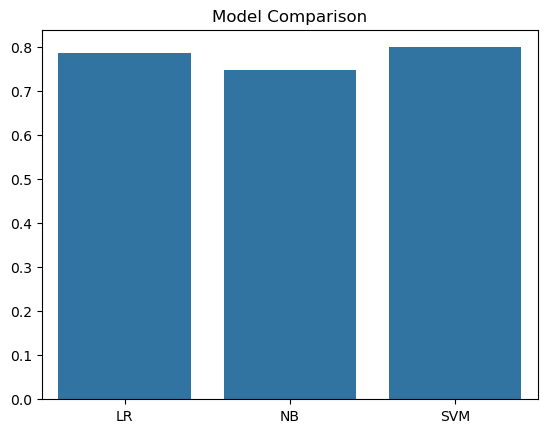

In [23]:
models = ['LR','NB','SVM']
scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_svm)
]

sns.barplot(x=models, y=scores)
plt.title("Model Comparison")
plt.show()

In [24]:
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Naive Bayes:", accuracy_score(y_test, y_pred_nb))
print("SVM:", accuracy_score(y_test, y_pred_svm))

Logistic Regression: 0.7847222222222222
Naive Bayes: 0.7465277777777778
SVM: 0.7986111111111112


In [25]:
print("\nSVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))


SVM Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.89      0.88       111
           1       0.67      0.09      0.16        44
           2       0.76      0.95      0.85       133

    accuracy                           0.80       288
   macro avg       0.76      0.65      0.63       288
weighted avg       0.78      0.80      0.75       288



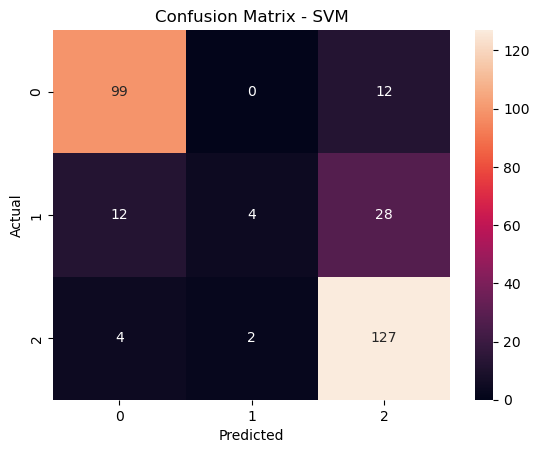

In [26]:
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

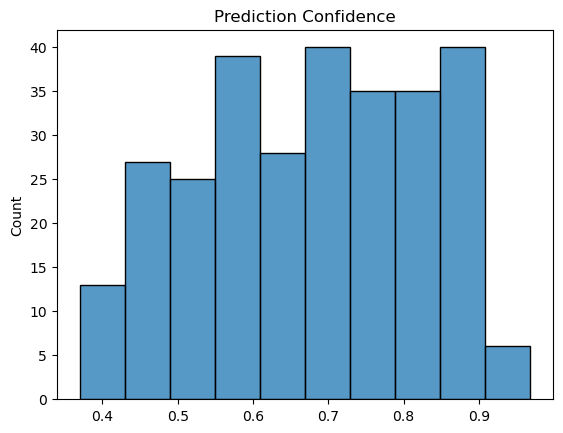

In [27]:
probs = lr.predict_proba(X_test)
confidence = probs.max(axis=1)

sns.histplot(confidence)
plt.title("Prediction Confidence")
plt.show()

In [28]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english"
)

print(classifier("This product is amazing!"))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.9998860359191895}]


In [29]:
TfidfVectorizer(ngram_range=(1,2), max_features=5000)
LinearSVC() 

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand